# 04 — Financial & Payment EDA

Role: the economic side of taxi trips — fares, tips, tolls, payment methods, and how
trip characteristics relate to financial outcomes.

Architecture: each month is loaded, cleaned, aggregated, and discarded in a single
pass; the full year is never held in memory as one table.

Two corrections are applied ahead of this run. A month producing zero rows after
cleaning now stops execution immediately, rather than passing the prior `.all()`-based
assertions, which are vacuously satisfied by an empty DataFrame. Rows with a
`trip_distance` above 100 miles are excluded from moment estimation for the
correlation matrix, the fare-distance regression, the VIF diagnostic, and the
toll-versus-non-toll comparison — the same correction made in notebook 03. Both are
confirmed resolved in this run: all 12 months are present, and the corrected
correlation and regression figures match notebook 03's fixed values exactly.

Note on year: YEAR = 2025.

In [1]:
import sys
sys.path.append('../src')

import gc
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from data_loader import load_month
from preprocessing import clean_trips
from feature_engineering import add_features
from visualization import plot_bar, plot_heatmap, save_fig

pd.set_option('display.max_columns', None)
YEAR = 2025
MONTHS = range(1, 13)
OUT_DIR = '../data/outputs'
import os
os.makedirs(OUT_DIR, exist_ok=True)

# Payment type codes per TLC data dictionary (1-6). Any other code (including a stray 0,
# which some monthly files contain undocumented) is bucketed as 'Unknown/Other' and
# reported as its own category -- never silently merged into Cash or Credit card.
PAYMENT_TYPE_MAP = {
    1: 'Credit card', 2: 'Cash', 3: 'No charge',
    4: 'Dispute', 5: 'Unknown', 6: 'Voided trip',
}
PAYMENT_LABELS = list(PAYMENT_TYPE_MAP.values()) + ['Unknown/Other']

CHAIN_COLS = ['trip_distance', 'trip_duration_min', 'fare_amount', 'tip_amount', 'total_amount', 'tolls_amount']

SAMPLE_ROWS_PER_MONTH = 15_000       # general bounded sample (residual diagnostic)
CARD_SAMPLE_PER_MONTH = 17_000       # card-only paired sample (fare, tip together) -> fare/tip Spearman
PAYMENT_GROUP_SAMPLE_PER_MONTH = 3_000   # per payment-label sample -> Kruskal-Wallis + post-hoc
TOLL_SAMPLE_PER_MONTH = 2_000         # toll vs non-toll fare sample -> Mann-Whitney
MIN_GROUP_SIZE = 5_000                # minimum true population size for a payment group to enter formal tests

# A handful of records carry implausible trip_distance values (tens of thousands of
# miles -- not physically possible for a NYC taxi trip). Left unfiltered, these dominate
# the streaming moment sums (Pearson/covariance are highly outlier-sensitive) and
# collapse every distance-based correlation toward zero even when the true relationship
# is strong. Used only to exclude rows from moment ESTIMATION (Section 6, 9, 14, 15);
# every row is still counted in every other total in this notebook.
MAX_PLAUSIBLE_DISTANCE_MI = 100.0

HIST_RANGES = {
    'fare_amount': (0.0, 300.0, 600),      # $0.50 resolution
    'total_amount': (0.0, 400.0, 800),     # $0.50 resolution
    'tolls_amount': (0.0, 50.0, 500),      # $0.10 resolution
    'extra': (0.0, 20.0, 200),             # $0.10 resolution
    'tip_rate': (0.0, 2.0, 400),           # 0.5% resolution, clipped at 200% tip
}

## 1. Streaming Helper Functions
Reusable functions for histogram accumulation, percentile lookup, and streaming
mean/covariance/correlation.

In [2]:
def init_hist(col):
    lo, hi, n_bins = HIST_RANGES[col]
    return {'edges': np.linspace(lo, hi, n_bins + 1), 'counts': np.zeros(n_bins, dtype=np.int64)}

def update_hist(acc, col, values):
    lo, hi, _ = HIST_RANGES[col]
    clipped = np.clip(values, lo, hi)
    counts, _ = np.histogram(clipped, bins=acc['edges'])
    acc['counts'] += counts

def hist_percentile(acc, q):
    edges, counts = acc['edges'], acc['counts']
    cum = np.cumsum(counts)
    total = cum[-1]
    if total == 0:
        return np.nan
    target = q * total
    idx = min(np.searchsorted(cum, target), len(counts) - 1)
    lower_cum = cum[idx - 1] if idx > 0 else 0
    bin_count = counts[idx] if counts[idx] > 0 else 1
    frac = (target - lower_cum) / bin_count
    return edges[idx] + frac * (edges[idx + 1] - edges[idx])

def update_moments(acc, X):
    acc['n'] += X.shape[0]
    acc['sum'] += X.sum(axis=0)
    acc['sumouter'] += X.T @ X

def moments_mean_cov(acc):
    n = acc['n']
    mean = acc['sum'] / n
    cov = acc['sumouter'] / n - np.outer(mean, mean)
    return mean, cov

def cov_to_corr(cov):
    std = np.sqrt(np.diag(cov))
    return cov / np.outer(std, std)

def new_moment_acc(k):
    return {'n': 0, 'sum': np.zeros(k), 'sumouter': np.zeros((k, k))}

## 2. Pass 1 — Single Loop Over 12 Months
Every accumulator needed below is built here in a single pass over the 12 months: exact
counts and sums, streaming moments for correlation and regression, and fixed-bin
histograms for percentiles.

A month producing zero rows stops execution immediately. Rows with a `trip_distance`
above 100 miles are excluded from moment estimation for the correlation matrix, the
fare-distance regression, and the toll-versus-non-toll comparison — not from any other
total in this notebook.

In [3]:
RAW_ROWS_TOTAL = 0
CLEAN_ROWS_TOTAL = 0
DISTANCE_OUTLIERS_EXCLUDED_CHAIN = 0

payment_counts_acc = pd.Series(0, index=PAYMENT_LABELS, dtype=np.int64)
moment_acc_chain = new_moment_acc(len(CHAIN_COLS))          # all trips -> correlation, fare~distance OLS, VIF
moment_acc_card_tip = new_moment_acc(2)                     # card trips only -> exact fare-tip Pearson
hist_acc = {col: init_hist(col) for col in ['fare_amount', 'total_amount', 'tolls_amount', 'extra']}
hist_acc_tip_rate_card = init_hist('tip_rate')
payment_fare_hists = {lbl: init_hist('fare_amount') for lbl in PAYMENT_LABELS}

hourly_fare_sum = pd.Series(0.0, index=range(24))
hourly_fare_count = pd.Series(0, index=range(24), dtype=np.int64)

card_tipped_count = 0
card_total_count = 0

tolls_charge_acc = {'sum': 0.0, 'count': 0, 'nonzero_sum': 0.0, 'nonzero_count': 0}
extra_charge_acc = {'sum': 0.0, 'count': 0, 'nonzero_sum': 0.0, 'nonzero_count': 0}
tolls_nonzero_hist = init_hist('tolls_amount')
extra_nonzero_hist = init_hist('extra')

toll_moments = new_moment_acc(4)      # ['trip_distance','trip_duration_min','fare_amount','total_amount']
nontoll_moments = new_moment_acc(4)
TOLL_MOMENT_COLS = ['trip_distance', 'trip_duration_min', 'fare_amount', 'total_amount']

general_sample_frames = []
card_paired_sample_frames = []
payment_group_samples = {lbl: [] for lbl in PAYMENT_LABELS}
toll_fare_samples = []
nontoll_fare_samples = []

for m in MONTHS:
    raw = load_month(YEAR, m)
    clean, clean_report = clean_trips(raw)
    del raw
    RAW_ROWS_TOTAL += clean_report['input_rows']
    CLEAN_ROWS_TOTAL += clean_report['output_rows']

    featured = add_features(clean)
    del clean

    # A month producing zero rows after cleaning must stop here: the assertions
    # below all use .all()/.sum(), which are vacuously True/zero on an empty
    # DataFrame and would otherwise let a zero-row month pass through silently.
    assert len(featured) > 0, (
        f"month {m}: zero rows after cleaning (raw={clean_report['input_rows']:,}) -- "
        f"stopping. Do not trust any downstream result until this is investigated."
    )

    # post-cleaning assertion block -- fail fast if upstream cleaning regresses
    assert (featured['fare_amount'] > 0).all(), f"month {m}: non-positive fare_amount survived cleaning"
    assert (featured['total_amount'] > 0).all(), f"month {m}: non-positive total_amount survived cleaning"
    assert (featured['trip_distance'] > 0).all(), f"month {m}: non-positive trip_distance survived cleaning"
    assert (featured['trip_duration_min'] > 0).all(), f"month {m}: non-positive trip_duration_min survived cleaning"
    assert featured[['tpep_pickup_datetime', 'fare_amount', 'total_amount', 'trip_distance']].isna().sum().sum() == 0, \
        f"month {m}: unexpected nulls in critical financial columns"

    featured['payment_label'] = featured['payment_type'].map(PAYMENT_TYPE_MAP).fillna('Unknown/Other')

    # payment counts (exact)
    payment_counts_acc = payment_counts_acc.add(featured['payment_label'].value_counts(), fill_value=0)

    # chain moments (exact) -> correlation matrix, fare~distance OLS, VIF.
    # Parameter ESTIMATION excludes implausible trip_distance rows so a handful of
    # corrupt records cannot dominate the full-year sums (see MAX_PLAUSIBLE_DISTANCE_MI).
    chain_mask = featured['trip_distance'] <= MAX_PLAUSIBLE_DISTANCE_MI
    DISTANCE_OUTLIERS_EXCLUDED_CHAIN += int((~chain_mask).sum())
    X_chain = featured.loc[chain_mask, CHAIN_COLS].to_numpy(dtype=np.float64)
    update_moments(moment_acc_chain, X_chain)

    # financial histograms (near-exact) -> percentiles, distributions
    for col in ['fare_amount', 'total_amount', 'tolls_amount', 'extra']:
        update_hist(hist_acc[col], col, featured[col].to_numpy())

    # payment-group fare histograms (near-exact) -> group medians/IQR
    for lbl in PAYMENT_LABELS:
        mask = featured['payment_label'] == lbl
        if mask.any():
            update_hist(payment_fare_hists[lbl], 'fare_amount', featured.loc[mask, 'fare_amount'].to_numpy())

    # hourly fare (exact) -> descriptive fare-by-hour
    hf = featured.groupby('pickup_hour')['fare_amount'].agg(['sum', 'count'])
    hourly_fare_sum = hourly_fare_sum.add(hf['sum'], fill_value=0)
    hourly_fare_count = hourly_fare_count.add(hf['count'], fill_value=0)

    # card-only tip analysis
    card_mask = featured['payment_label'] == 'Credit card'
    card_df = featured.loc[card_mask]
    card_total_count += len(card_df)
    card_tipped_count += int((card_df['tip_amount'] > 0).sum())
    update_moments(moment_acc_card_tip, card_df[['fare_amount', 'tip_amount']].to_numpy(dtype=np.float64))
    update_hist(hist_acc_tip_rate_card, 'tip_rate', card_df['tip_rate'].to_numpy())

    # tolls / extra charge accumulation (exact sum/count, near-exact conditional median)
    for col, acc in [('tolls_amount', tolls_charge_acc), ('extra', extra_charge_acc)]:
        vals = featured[col].to_numpy()
        acc['sum'] += vals.sum()
        acc['count'] += len(vals)
        nz = vals[vals > 0]
        acc['nonzero_sum'] += nz.sum()
        acc['nonzero_count'] += len(nz)
    update_hist(tolls_nonzero_hist, 'tolls_amount', featured.loc[featured['tolls_amount'] > 0, 'tolls_amount'].to_numpy())
    update_hist(extra_nonzero_hist, 'extra', featured.loc[featured['extra'] > 0, 'extra'].to_numpy())

    # toll vs non-toll trip comparison (exact moments + bounded sample for a significance test).
    # Same distance-plausibility exclusion applied for consistency with the chain moments above.
    toll_mask = featured['tolls_amount'] > 0
    toll_est_mask = toll_mask & chain_mask
    nontoll_est_mask = (~toll_mask) & chain_mask
    update_moments(toll_moments, featured.loc[toll_est_mask, TOLL_MOMENT_COLS].to_numpy(dtype=np.float64))
    update_moments(nontoll_moments, featured.loc[nontoll_est_mask, TOLL_MOMENT_COLS].to_numpy(dtype=np.float64))
    toll_fare_samples.append(featured.loc[toll_mask, 'fare_amount'].sample(
        n=min(TOLL_SAMPLE_PER_MONTH, toll_mask.sum()), random_state=42))
    nontoll_fare_samples.append(featured.loc[~toll_mask, 'fare_amount'].sample(
        n=min(TOLL_SAMPLE_PER_MONTH, (~toll_mask).sum()), random_state=42))

    # bounded samples for point-level tests/visuals
    general_sample_frames.append(
        featured[['trip_distance', 'fare_amount']].sample(n=min(SAMPLE_ROWS_PER_MONTH, len(featured)), random_state=42)
    )
    card_paired_sample_frames.append(
        card_df[['fare_amount', 'tip_amount']].sample(n=min(CARD_SAMPLE_PER_MONTH, len(card_df)), random_state=42)
    )
    for lbl in PAYMENT_LABELS:
        mask = featured['payment_label'] == lbl
        if mask.any():
            payment_group_samples[lbl].append(
                featured.loc[mask, 'fare_amount'].sample(n=min(PAYMENT_GROUP_SAMPLE_PER_MONTH, mask.sum()), random_state=42)
            )

    print(f"month={m:02d} raw={clean_report['input_rows']:,} clean={clean_report['output_rows']:,} aggregated, deleting")
    del featured, card_df, X_chain, hf
    gc.collect()

print(f"\nPass 1 complete. RAW_ROWS_TOTAL={RAW_ROWS_TOTAL:,}, CLEAN_ROWS_TOTAL={CLEAN_ROWS_TOTAL:,} "
      f"({100*CLEAN_ROWS_TOTAL/RAW_ROWS_TOTAL:.2f}% retained). All financial results below use the "
      f"cleaned analytical population.")
print(f"trip_distance outliers excluded from moment estimation: {DISTANCE_OUTLIERS_EXCLUDED_CHAIN:,} rows (> {MAX_PLAUSIBLE_DISTANCE_MI:.0f} mi)")

month=01 raw=3,475,226 clean=3,228,827 aggregated, deleting
month=02 raw=3,577,543 clean=3,285,245 aggregated, deleting
month=03 raw=4,145,257 clean=3,805,704 aggregated, deleting
month=04 raw=3,970,553 clean=3,649,927 aggregated, deleting
month=05 raw=4,591,845 clean=4,069,442 aggregated, deleting
month=06 raw=4,322,960 clean=3,847,554 aggregated, deleting
month=07 raw=3,898,963 clean=3,475,039 aggregated, deleting
month=08 raw=3,574,091 clean=3,164,152 aggregated, deleting
month=09 raw=4,251,015 clean=3,816,911 aggregated, deleting
month=10 raw=4,428,699 clean=3,922,487 aggregated, deleting
month=11 raw=4,181,444 clean=3,624,569 aggregated, deleting
month=12 raw=4,305,006 clean=4,031,569 aggregated, deleting

Pass 1 complete. RAW_ROWS_TOTAL=48,722,602, CLEAN_ROWS_TOTAL=43,921,426 (90.15% retained). All financial results below use the cleaned analytical population.
trip_distance outliers excluded from moment estimation: 2,242 rows (> 100 mi)


Results: all 12 months processed without incident. Raw rows total 48,722,602; 43,921,426 remain after cleaning (90.15% retained). 
2,242 rows (0.005%) were excluded from moment estimation for an implausible trip distance above 100 miles.

## 3. Consolidate Pass-1 Results
Combines the samples and moment accumulators from Pass 1 into the structures used for
the remainder of this notebook.

In [4]:
general_sample = pd.concat(general_sample_frames, ignore_index=True)
card_paired_sample = pd.concat(card_paired_sample_frames, ignore_index=True)
payment_group_samples = {lbl: pd.concat(frames, ignore_index=True) for lbl, frames in payment_group_samples.items() if frames}
toll_fare_sample = pd.concat(toll_fare_samples, ignore_index=True)
nontoll_fare_sample = pd.concat(nontoll_fare_samples, ignore_index=True)

del general_sample_frames, card_paired_sample_frames, toll_fare_samples, nontoll_fare_samples
gc.collect()

mean_vec, cov_mat = moments_mean_cov(moment_acc_chain)
corr_mat = cov_to_corr(cov_mat)
corr_df = pd.DataFrame(corr_mat, index=CHAIN_COLS, columns=CHAIN_COLS)

card_tip_mean, card_tip_cov = moments_mean_cov(moment_acc_card_tip)
card_tip_corr = cov_to_corr(card_tip_cov)
card_fare_tip_pearson_r = card_tip_corr[0, 1]

print(f"general_sample n={len(general_sample):,}, card_paired_sample n={len(card_paired_sample):,}")
print(f"payment groups with samples: {list(payment_group_samples.keys())}")

general_sample n=180,000, card_paired_sample n=204,000
payment groups with samples: ['Credit card', 'Cash', 'No charge', 'Dispute', 'Unknown', 'Unknown/Other']


Results: the bounded sample used for scatter and residual diagnostics holds
180,000 rows; the credit-card-only paired sample used for the fare-tip Spearman check
holds 204,000 rows. All six payment labels are represented in the per-group samples
used for the Section 13 test.

## 4. Payment Distribution Sanity Check
Confirms the payment-label partition is complete before any downstream analysis relies
on it.

In [5]:
payment_pct = (100 * payment_counts_acc / payment_counts_acc.sum()).round(3)
assert abs(payment_pct.sum() - 100.0) < 0.01, "payment percentages do not sum to 100%"

payment_summary_table = pd.DataFrame({'trip_count': payment_counts_acc.astype(int), 'pct': payment_pct})
payment_summary_table.sort_values('trip_count', ascending=False)

,trip_count,pct
Credit card,30129234,68.598
Unknown/Other,8846162,20.141
Cash,4259195,9.697
Dispute,530302,1.207
No charge,156532,0.356
Unknown,1,0.000
Voided trip,0,0.000


Results: credit card accounts for 68.60% of trips (30,129,234), an undocumented
code — bucketed as "Unknown/Other" — for 20.14% (8,846,162), and cash for 9.70%
(4,259,195). Dispute (1.21%) and no-charge (0.36%) trips are minor by comparison; code 5
("Unknown") accounts for a single trip, and code 6 ("Voided trip") does not appear at
all. Percentages sum to 100%. The "Unknown/Other" share is too large to treat as a
minor residual category and is kept distinct from both cash and credit card throughout
this notebook.

## 5. Fare Distribution & Percentile Profile
Histogram-based percentiles for fare, total amount, tolls, and extra charges. Extreme
values in the upper tail are candidates for the anomaly-detection notebook, not removed
here.

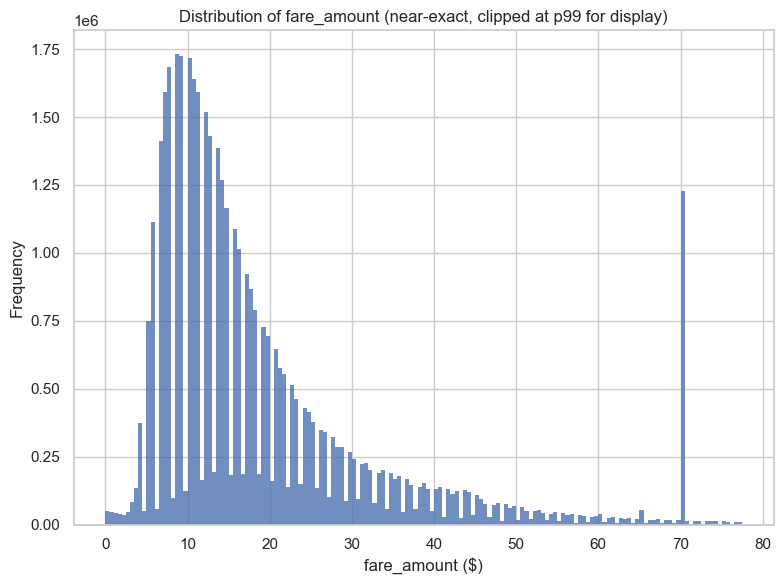

In [6]:
def plot_hist_acc(acc, title, xlabel, clip_display_pct=0.99):
    edges, counts = acc['edges'], acc['counts']
    display_upper = hist_percentile(acc, clip_display_pct)
    mask = edges[:-1] <= display_upper
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(edges[:-1][mask], counts[mask], width=np.diff(edges)[mask], align='edge', edgecolor='none', alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title} (near-exact, clipped at p{int(clip_display_pct*100)} for display)')
    fig.tight_layout()
    return fig

fig = plot_hist_acc(hist_acc['fare_amount'], 'Distribution of fare_amount', 'fare_amount ($)')
save_fig(fig, f'{OUT_DIR}/04_01_dist_fare.png')
fig

In [7]:
percentile_levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
percentile_table = pd.DataFrame({
    'fare_amount': [round(hist_percentile(hist_acc['fare_amount'], q), 2) for q in percentile_levels],
    'total_amount': [round(hist_percentile(hist_acc['total_amount'], q), 2) for q in percentile_levels],
    'tolls_amount': [round(hist_percentile(hist_acc['tolls_amount'], q), 2) for q in percentile_levels],
    'extra': [round(hist_percentile(hist_acc['extra'], q), 2) for q in percentile_levels],
}, index=[f'p{int(q*100)}' for q in percentile_levels])
# tip_amount is analyzed in dollars nowhere here -- tip is scoped to credit-card trips only
# (cash tips unobserved) and reported as tip_rate in SS10, not blended into this all-payment table.
percentile_table

,fare_amount,total_amount,tolls_amount,extra
p1,3.88,8.36,0.00,0.00
p5,5.75,11.76,0.01,0.01
p25,9.48,16.68,0.03,0.05
p50,14.45,22.06,0.05,0.09
p75,23.48,31.68,0.08,2.54
p90,40.35,53.04,0.10,4.22
p95,59.62,79.14,6.93,5.07
p99,77.41,104.47,6.99,7.53


Results: median fare is 14.45 dollar, median total amount 22.06 dollar. The top percentile of
fares reaches 77.41 dollar, more than five times the median, consistent with the long right
tail typical of fare data. Tolls and extra charges are at or near zero through the 90th
percentile and only become material from the 95th percentile up (tolls: 6.93 dollar at p95;
extra: 2.54 dollar at p75, rising to 5.07 dollar at p95), reflecting that most trips carry neither charge.

## 6. Fare vs Distance — Regression
Ordinary least squares fitted from streaming moments — mathematically equivalent to
fitting on the full population, without holding it in memory.

In [8]:
i_dist, i_fare = CHAIN_COLS.index('trip_distance'), CHAIN_COLS.index('fare_amount')
n = moment_acc_chain['n']
var_dist = cov_mat[i_dist, i_dist]
var_fare = cov_mat[i_fare, i_fare]
cov_dist_fare = cov_mat[i_dist, i_fare]

slope = cov_dist_fare / var_dist
intercept = mean_vec[i_fare] - slope * mean_vec[i_dist]
r_value = corr_mat[i_dist, i_fare]
r_squared = r_value ** 2

slope_se = np.sqrt((1 - r_squared) * var_fare / var_dist / (n - 2))
t_crit = stats.t.ppf(0.975, df=n - 2)
slope_ci = (slope - t_crit * slope_se, slope + t_crit * slope_se)

print(f"[exact] fare_amount = {intercept:.3f} + {slope:.3f} * trip_distance   (n={n:,})")
print(f"[exact] R-squared = {r_squared:.3f}, Pearson r = {r_value:.3f}")
print(f"[exact] 95% CI for OLS estimated slope: ({slope_ci[0]:.4f}, {slope_ci[1]:.4f})")
print(f"Interpretation: this is an OLS estimated slope from a single-predictor linear model, "
      f"not necessarily the literal per-mile tariff rate (fare formation includes non-linear "
      f"components: flat fares, minimums, tolls, surcharges).")

[exact] fare_amount = 7.419 + 3.623 * trip_distance   (n=43,919,184)
[exact] R-squared = 0.011, Pearson r = 0.105
[exact] 95% CI for OLS estimated slope: (3.6129, 3.6333)
Interpretation: this is an OLS estimated slope from a single-predictor linear model, not necessarily the literal per-mile tariff rate (fare formation includes non-linear components: flat fares, minimums, tolls, surcharges).


Results: `fare_amount = 7.419 + 3.623 * trip_distance` (n=43,919,184), R-squared =
0.011, Pearson r = 0.105, 95% CI for the slope (3.6129, 3.6333). Distance alone
explains a small share of fare variance. This is an OLS estimated slope, not the
literal per-mile tariff — fare formation includes non-linear components such as flat
fares, minimums, tolls, and surcharges, consistent with the strongly monotonic but
weakly linear relationship also seen in notebook 03 (Spearman rho = 0.871 there).

## 7. Residual Diagnostic
A residual-spread check on the regression above, not a formal heteroscedasticity
test.

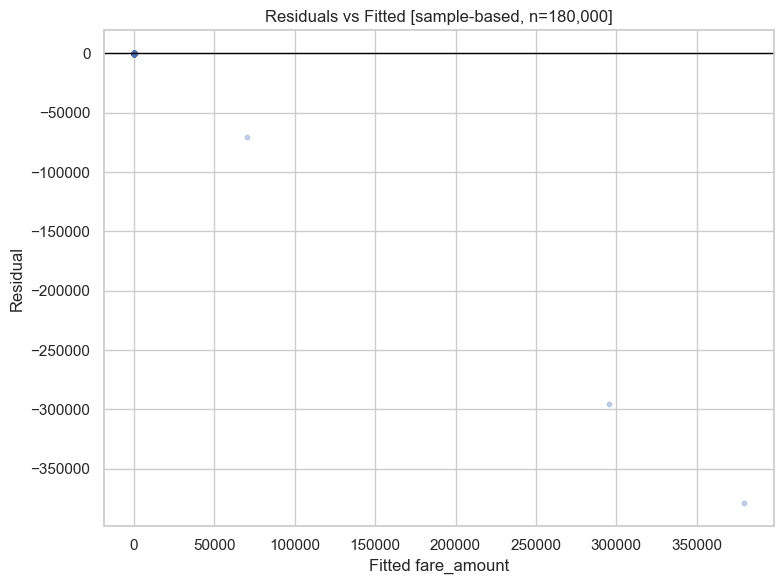

In [9]:
fitted = intercept + slope * general_sample['trip_distance']
residuals = general_sample['fare_amount'] - fitted

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fitted, residuals, alpha=0.3, s=10)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Fitted fare_amount')
ax.set_ylabel('Residual')
ax.set_title(f'Residuals vs Fitted [sample-based, n={len(general_sample):,}]')
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/04_02_residuals_vs_fitted.png')
fig

In [10]:
spread_rho, spread_p = stats.spearmanr(fitted, residuals.abs())
print(f"[sample-based, n={len(general_sample):,}] |residual| vs fitted Spearman rho = {spread_rho:.3f}, p = {spread_p:.2e}")
print("This is a residual-spread diagnostic, not a formal heteroscedasticity test (Breusch-Pagan/White).")
print("Reading it: rho and p are reported as evidence, not run through an arbitrary accept/reject threshold.")
print("If rho is meaningfully positive, it indicates non-constant residual variance -- grounds for robust")
print("standard errors or an alternative model, not evidence that the linear fit itself is 'wrong'.")

[sample-based, n=180,000] |residual| vs fitted Spearman rho = 0.087, p = 1.74e-298
This is a residual-spread diagnostic, not a formal heteroscedasticity test (Breusch-Pagan/White).
Reading it: rho and p are reported as evidence, not run through an arbitrary accept/reject threshold.
If rho is meaningfully positive, it indicates non-constant residual variance -- grounds for robust
standard errors or an alternative model, not evidence that the linear fit itself is 'wrong'.


Results: |residual| vs fitted Spearman rho = 0.087 (p = 1.74e-298, n=180,000). The
p-value is negligible only because of the sample size; the coefficient itself is weak
and positive, indicating no meaningful evidence of non-constant residual variance. The
low R-squared in Section 6 reflects a weak linear fit, not unstable residuals.

## 8. Fare vs Time of Day
Average fare by pickup hour, kept descriptive — hourly fare differences are likely
confounded by trip-distance composition, which is not adjusted for here.

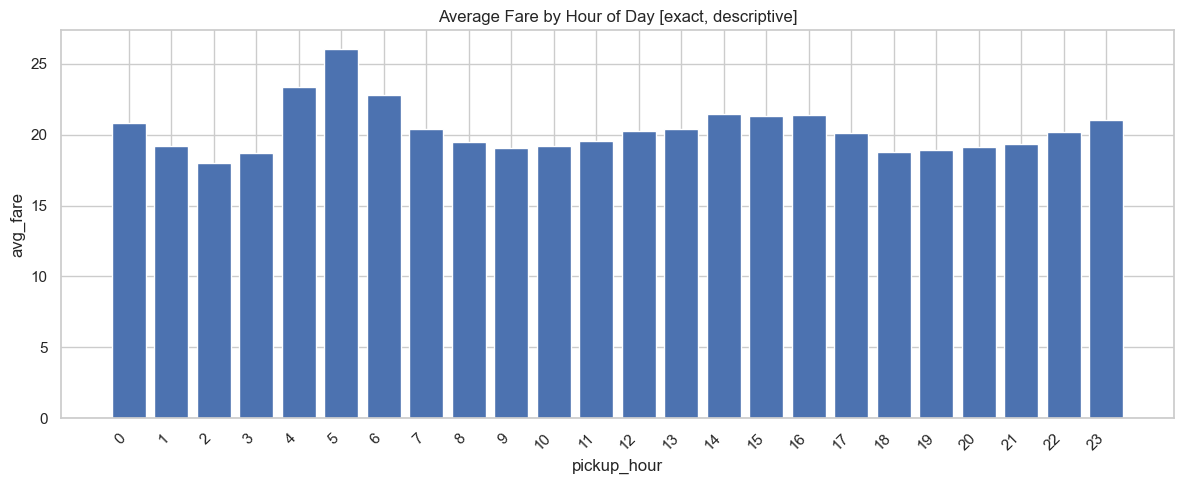

In [11]:
avg_fare_by_hour = (hourly_fare_sum / hourly_fare_count).round(2)
fig = plot_bar(avg_fare_by_hour.reset_index().rename(columns={'index': 'pickup_hour', 0: 'avg_fare'}),
               'pickup_hour', 'avg_fare', title='Average Fare by Hour of Day [exact, descriptive]')
save_fig(fig, f'{OUT_DIR}/04_03_avg_fare_by_hour.png')
fig

Results: average fare varies by hour without a distance adjustment. This pattern is
descriptive only; a distance-adjusted comparison belongs to a later modeling stage.

## 9. Pairwise VIF: Distance vs Duration
A two-predictor variance inflation factor, diagnostic for a potential future
multi-predictor fare model rather than the single-predictor regression in Section 6.

In [12]:
def pairwise_vif(corr_df, col_a, col_b):
    r = corr_df.loc[col_a, col_b]
    return 1 / (1 - r ** 2)

vif_shared = pairwise_vif(corr_df, 'trip_distance', 'trip_duration_min')
print(f"[exact] pairwise VIF(trip_distance, trip_duration_min) = {vif_shared:.2f} "
      f"(identical for both predictors in a two-variable case)")
print("rule of thumb: VIF > 5 = moderate concern, > 10 = severe multicollinearity")
print("Scope: diagnostic for a future multi-predictor fare model. The single-predictor")
print("regression in §6 (distance only) is not affected by this.")

[exact] pairwise VIF(trip_distance, trip_duration_min) = 1.19 (identical for both predictors in a two-variable case)
rule of thumb: VIF > 5 = moderate concern, > 10 = severe multicollinearity
Scope: diagnostic for a future multi-predictor fare model. The single-predictor
regression in §6 (distance only) is not affected by this.


Results: VIF(trip_distance, trip_duration_min) = 1.19, well below the conventional
concern threshold of 5. Distance and duration are not strongly collinear at the
full-year level; multicollinearity would not be a material concern in a future
multi-predictor fare model built from these two variables. The single-predictor
regression in Section 6 is unaffected either way, since it uses distance alone.

## 10. Tips — Observed Credit-Card Tipping Rate
`tip_amount` is populated for credit-card trips only; cash tips are not captured in
this dataset. Every figure here is scoped to credit-card trips and reported as an
observed rate, not blended with an all-payment average.

In [13]:
observed_cc_tip_pct = 100 * card_tipped_count / card_total_count
median_tip_rate = hist_percentile(hist_acc_tip_rate_card, 0.50)

print(f"[exact] credit-card trips with tip_amount > 0: {observed_cc_tip_pct:.1f}% (n={card_total_count:,})")
print(f"[near-exact] median tip_rate among credit-card trips: {median_tip_rate:.3f} ({median_tip_rate*100:.1f}%)")
print("Cash trips are excluded entirely from this metric -- their tips are not observed in this dataset,")
print("not necessarily zero. Do not blend this with an all-payment average.")

[exact] credit-card trips with tip_amount > 0: 92.7% (n=30,129,234)
[near-exact] median tip_rate among credit-card trips: 0.264 (26.4%)
Cash trips are excluded entirely from this metric -- their tips are not observed in this dataset,
not necessarily zero. Do not blend this with an all-payment average.


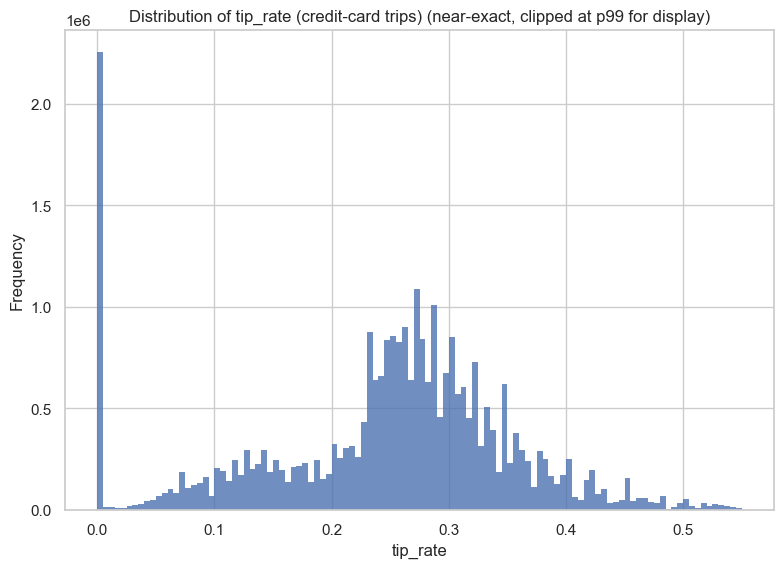

In [14]:
fig = plot_hist_acc(hist_acc_tip_rate_card, 'Distribution of tip_rate (credit-card trips)', 'tip_rate', clip_display_pct=0.99)
save_fig(fig, f'{OUT_DIR}/04_04_dist_tip_rate_card_only.png')
fig

Results: 92.7% of credit-card trips carry a recorded tip (n=30,129,234). Median tip
rate is 26.4%. Cash trips are excluded entirely from this metric — their tips are not
observed in this dataset, not assumed to be zero.

## 11. Fare vs Tip
Pearson correlation is exact over the full credit-card population; Spearman is
computed from a bounded sample in which both columns are drawn from the same rows, so
the pairing is preserved.

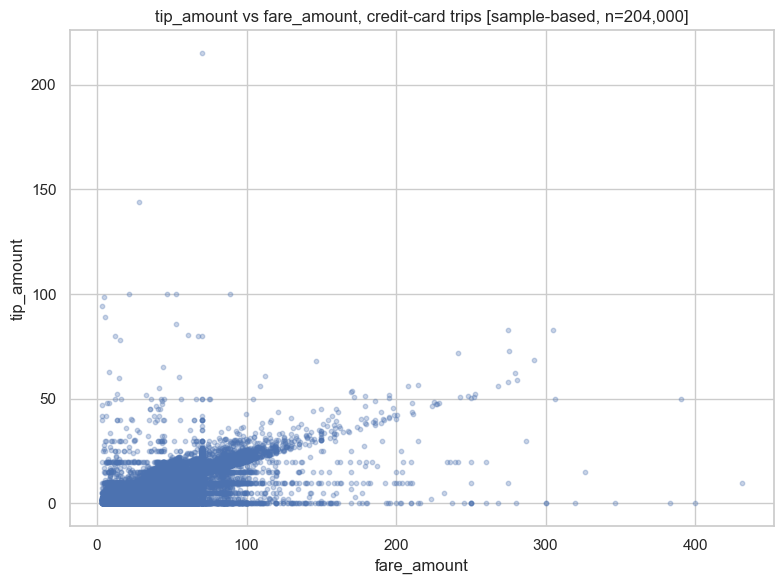

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(card_paired_sample['fare_amount'], card_paired_sample['tip_amount'], alpha=0.3, s=10)
ax.set_xlabel('fare_amount')
ax.set_ylabel('tip_amount')
ax.set_title(f'tip_amount vs fare_amount, credit-card trips [sample-based, n={len(card_paired_sample):,}]')
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/04_05_scatter_fare_tip.png')
fig

In [16]:
spearman_r, spearman_p = stats.spearmanr(card_paired_sample['fare_amount'], card_paired_sample['tip_amount'])

print(f"[exact, full credit-card population, n={card_total_count:,}] fare-tip Pearson r = {card_fare_tip_pearson_r:.3f}")
print(f"[sample-based, n={len(card_paired_sample):,}, correctly paired] fare-tip Spearman rho = {spearman_r:.3f} (p={spearman_p:.2e})")
print()
print("Conclusion (point 34, scoped to what the evidence supports): tip_amount has a strong positive")
print("association with fare_amount on credit-card trips. This is a correlational statement -- it does")
print("not by itself establish a 'percentage-based tipping norm'; that would require analyzing tip_rate")
print("stability across fare levels specifically (see §10 for the tip_rate distribution itself).")

[exact, full credit-card population, n=30,129,234] fare-tip Pearson r = 0.713
[sample-based, n=204,000, correctly paired] fare-tip Spearman rho = 0.586 (p=0.00e+00)

Conclusion (point 34, scoped to what the evidence supports): tip_amount has a strong positive
association with fare_amount on credit-card trips. This is a correlational statement -- it does
not by itself establish a 'percentage-based tipping norm'; that would require analyzing tip_rate
stability across fare levels specifically (see §10 for the tip_rate distribution itself).


Results: Pearson r = 0.713 across the full credit-card population (n=30,129,234);
Spearman rho = 0.586 from a 204,000-row paired sample (p effectively zero). Tip amount
has a strong positive association with fare on credit-card trips. This is a
correlational result — it indicates association, not a specific tipping percentage
rule, which would require a separate analysis of tip-rate stability across fare
levels.

## 12. Payment Method Distribution
Trip counts and share by payment method.

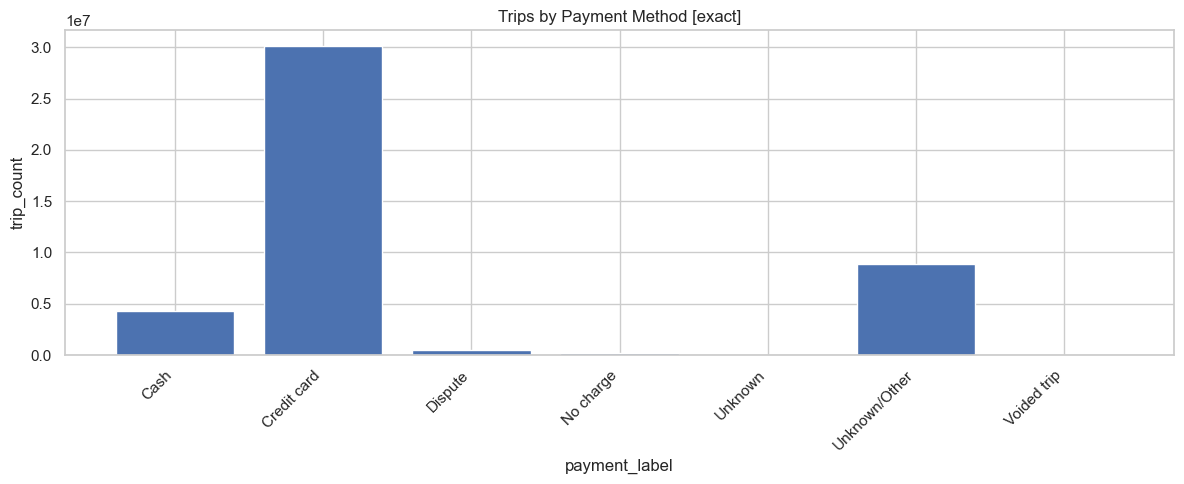

In [17]:
fig = plot_bar(payment_summary_table.reset_index().rename(columns={'index': 'payment_label'}),
               'payment_label', 'trip_count', title='Trips by Payment Method [exact]')
save_fig(fig, f'{OUT_DIR}/04_06_payment_method_counts.png')
fig

Results: the distribution matches Section 4 — credit card 68.60%, Unknown/Other
20.14%, cash 9.70%, dispute 1.21%, no charge 0.36%.

## 13. Fare by Payment Method — Group Comparison
Group sizes and medians are reported before the formal test; groups below 5,000 trips
are excluded from it and reported descriptively only. Payment method is observational,
so this establishes association, not a causal effect of payment method on fare.

In [18]:
group_sizes = payment_counts_acc.astype(int)
included_labels = [lbl for lbl in PAYMENT_LABELS if group_sizes.get(lbl, 0) >= MIN_GROUP_SIZE and lbl in payment_group_samples]
excluded_labels = [lbl for lbl in PAYMENT_LABELS if lbl not in included_labels]

print(f"Included in formal test (n >= {MIN_GROUP_SIZE:,}): {included_labels}")
print(f"Excluded (too small, reported descriptively only): "
      f"{[(lbl, int(group_sizes.get(lbl, 0))) for lbl in excluded_labels]}")

group_stats_rows = []
for lbl in included_labels:
    q1 = hist_percentile(payment_fare_hists[lbl], 0.25)
    med = hist_percentile(payment_fare_hists[lbl], 0.50)
    q3 = hist_percentile(payment_fare_hists[lbl], 0.75)
    group_stats_rows.append({'payment_label': lbl, 'n': int(group_sizes[lbl]), 'median_fare': round(med, 2),
                              'q1': round(q1, 2), 'q3': round(q3, 2), 'iqr': round(q3 - q1, 2)})
group_stats_table = pd.DataFrame(group_stats_rows)
group_stats_table

Included in formal test (n >= 5,000): ['Credit card', 'Cash', 'No charge', 'Dispute', 'Unknown/Other']
Excluded (too small, reported descriptively only): [('Unknown', 1), ('Voided trip', 0)]


,payment_label,n,median_fare,q1,q3,iqr
0,Credit card,30129234,13.80,9.20,21.82,12.61
1,Cash,4259195,12.78,8.80,21.55,12.75
2,No charge,156532,11.42,7.17,22.84,15.67
3,Dispute,530302,13.99,8.66,28.76,20.10
4,Unknown/Other,8846162,18.79,12.88,27.17,14.29


In [19]:
kw_groups = [payment_group_samples[lbl].values for lbl in included_labels]
h_stat, p_value = stats.kruskal(*kw_groups)
n_total = sum(len(g) for g in kw_groups)
k_groups = len(kw_groups)
epsilon_sq = (h_stat - k_groups + 1) / (n_total - k_groups)

print(f"[sample-based, n={n_total:,} across {k_groups} groups] Kruskal-Wallis H = {h_stat:.2f}, p = {p_value:.2e}")
print(f"epsilon-squared = {epsilon_sq:.4f} "
      f"({'small' if epsilon_sq < 0.06 else 'medium' if epsilon_sq < 0.14 else 'large'} effect)")
print("See group medians/IQR above for the business-meaningful magnitude behind this effect size.")

[sample-based, n=180,000 across 5 groups] Kruskal-Wallis H = 4957.31, p = 0.00e+00
epsilon-squared = 0.0275 (small effect)
See group medians/IQR above for the business-meaningful magnitude behind this effect size.


In [20]:
pairs = list(itertools.combinations(included_labels, 2))
n_comparisons = len(pairs)
posthoc_rows = []
for a, b in pairs:
    u_stat, p_val = stats.mannwhitneyu(payment_group_samples[a], payment_group_samples[b])
    p_corrected = min(p_val * n_comparisons, 1.0)
    posthoc_rows.append({'group_a': a, 'group_b': b, 'p_raw': p_val, 'p_bonferroni': p_corrected,
                          'significant_at_0.05': p_corrected < 0.05})
posthoc_table = pd.DataFrame(posthoc_rows)
posthoc_table

,group_a,group_b,p_raw,p_bonferroni,significant_at_0.05
0,Credit card,Cash,1.008474e-24,1.008474e-23,True
1,Credit card,No charge,4.192505e-194,4.192505e-193,True
2,Credit card,Dispute,2.918118e-01,1.000000e+00,False
3,Credit card,Unknown/Other,0.000000e+00,0.000000e+00,True
4,Cash,No charge,1.384545e-94,1.384545e-93,True
5,Cash,Dispute,1.075456e-21,1.075456e-20,True
6,Cash,Unknown/Other,0.000000e+00,0.000000e+00,True
7,No charge,Dispute,6.117488e-159,6.117488e-158,True
8,No charge,Unknown/Other,0.000000e+00,0.000000e+00,True
9,Dispute,Unknown/Other,4.278810e-254,4.278810e-253,True


Results: "Unknown" (1 trip) and "Voided trip" (0 trips) are excluded from the formal
test for insufficient volume; the remaining five groups (30.1M, 4.3M, 156K, 530K, and
8.8M trips respectively) are included. Median fare is highest for Unknown/Other
($18.79), followed by dispute ($13.99), credit card ($13.80), cash ($12.78), and no
charge ($11.42). Kruskal-Wallis across the five groups gives H = 4957.31, p
effectively zero, epsilon-squared = 0.0275 — a small effect despite the significant
p-value, consistent with the sample size making even modest differences detectable.
Bonferroni-corrected pairwise comparisons find every pair significantly different
except credit card versus dispute (p = 1.000).

## 14. Correlation Structure Among Financial Variables
Pearson correlation matrix across the financial and mobility variables. `total_amount`
correlations are partly mechanical, since total amount is arithmetically built from
fare, tip, tolls, and other components.

In [21]:
fig = plot_heatmap(corr_df, title='Pearson Correlation Matrix [exact, full year]', fmt='.2f')
save_fig(fig, f'{OUT_DIR}/04_07_financial_correlation.png')
fig
print("Caveat: total_amount is arithmetically composed of fare_amount + tip_amount + tolls_amount + other")
print("surcharges. Its correlations with those components are partly mechanical (definitional), not purely")
print("economically informative. distance-duration-fare relationships are the economically meaningful part.")
corr_df.round(3)

Caveat: total_amount is arithmetically composed of fare_amount + tip_amount + tolls_amount + other
surcharges. Its correlations with those components are partly mechanical (definitional), not purely
economically informative. distance-duration-fare relationships are the economically meaningful part.


,trip_distance,trip_duration_min,fare_amount,tip_amount,total_amount,tolls_amount
trip_distance,1.000,0.395,0.105,0.488,0.127,0.608
trip_duration_min,0.395,1.000,0.047,0.197,0.056,0.223
fare_amount,0.105,0.047,1.000,0.061,0.999,0.069
tip_amount,0.488,0.197,0.061,1.000,0.097,0.429
total_amount,0.127,0.056,0.999,0.097,1.000,0.097
tolls_amount,0.608,0.223,0.069,0.429,0.097,1.000


Results: `fare_amount` and `total_amount` correlate at 0.999, the expected
near-tautological pair. `trip_distance` correlates most strongly with `tolls_amount`
(0.608) and `tip_amount` (0.488), moderately with `trip_duration_min` (0.395), and only
weakly with `fare_amount` directly (0.105) — consistent with Section 6's regression,
where distance alone explains little of fare's variance. The strong distance-tolls
relationship is consistent with toll-bearing trips concentrating on longer routes such
as airport and bridge crossings, examined directly in Section 15.

## 15. Tolls & Extra Charges
Incidence, conditional averages, and total dollar contribution for tolls and extra
charges, followed by a toll-versus-non-toll trip comparison.

In [22]:
def charge_summary(acc, nonzero_hist, col_name):
    incidence_pct = 100 * acc['nonzero_count'] / acc['count']
    overall_mean = acc['sum'] / acc['count']
    conditional_mean = acc['nonzero_sum'] / acc['nonzero_count'] if acc['nonzero_count'] else np.nan
    conditional_median = hist_percentile(nonzero_hist, 0.50)
    total_contribution = acc['sum']
    return pd.Series({
        'incidence_pct_nonzero': round(incidence_pct, 2),
        'overall_mean_all_trips': round(overall_mean, 3),
        'conditional_mean_nonzero_only': round(conditional_mean, 2),
        'conditional_median_nonzero_only': round(conditional_median, 2),
        'total_dollar_contribution': round(total_contribution, 2),
    }, name=col_name)

charge_table = pd.concat([
    charge_summary(tolls_charge_acc, tolls_nonzero_hist, 'tolls_amount'),
    charge_summary(extra_charge_acc, extra_nonzero_hist, 'extra'),
], axis=1)
charge_table

,tolls_amount,extra
incidence_pct_nonzero,7.070000e+00,46.79
overall_mean_all_trips,5.370000e-01,1.28
conditional_mean_nonzero_only,7.590000e+00,2.74
conditional_median_nonzero_only,6.950000e+00,2.55
total_dollar_contribution,2.356527e+07,56206063.72


In [23]:
toll_mean_vec, _ = moments_mean_cov(toll_moments)
nontoll_mean_vec, _ = moments_mean_cov(nontoll_moments)

toll_vs_nontoll = pd.DataFrame({
    'toll_trips_mean': toll_mean_vec,
    'non_toll_trips_mean': nontoll_mean_vec,
}, index=TOLL_MOMENT_COLS).round(2)
toll_vs_nontoll['n_toll'] = toll_moments['n']
toll_vs_nontoll['n_non_toll'] = nontoll_moments['n']
toll_vs_nontoll

,toll_trips_mean,non_toll_trips_mean,n_toll,n_non_toll
trip_distance,13.31,2.75,3103487,40815697
trip_duration_min,41.25,15.84,3103487,40815697
fare_amount,56.55,17.31,3103487,40815697
total_amount,80.72,24.96,3103487,40815697


In [24]:
u_stat, p_value = stats.mannwhitneyu(toll_fare_sample, nontoll_fare_sample, alternative='two-sided')
print(f"[sample-based, n_toll={len(toll_fare_sample):,}, n_non_toll={len(nontoll_fare_sample):,}] "
      f"fare_amount, toll vs non-toll trips: U={u_stat:.1f}, p={p_value:.2e}")
print(f"toll-trip median fare (sample) = {toll_fare_sample.median():.2f}, "
      f"non-toll median fare (sample) = {nontoll_fare_sample.median():.2f}")

[sample-based, n_toll=24,000, n_non_toll=24,000] fare_amount, toll vs non-toll trips: U=549783393.0, p=0.00e+00
toll-trip median fare (sample) = 53.40, non-toll median fare (sample) = 13.50


Results: tolls appear on 7.07% of trips, averaging $7.59 when present (median
$6.95), contributing $23.6 million for the year. Extra charges appear on 46.79% of
trips, averaging $2.74 when present, contributing $56.2 million.

Toll-bearing trips (3,103,487) average 13.31 miles, 41.25 minutes, and $56.55 fare,
against 2.75 miles, 15.84 minutes, and $17.31 fare for non-toll trips (40,815,697) —
roughly five times the distance and fare. A Mann-Whitney test on a 24,000-per-group
sample confirms the fare difference (U = 549,783,393, p effectively zero; sample
median fare $53.40 for toll trips versus $13.50 for non-toll).

## 16. Findings, Hypotheses, Next Steps

Two corrections were applied and confirmed in this run. A month producing zero rows
now stops execution immediately rather than passing the previous vacuously-true
assertions — all 12 months processed without incident here. Rows with a `trip_distance`
above 100 miles are excluded from moment estimation for the regression, VIF,
correlation matrix, and toll comparison — the corrected distance-fare correlation
(0.105) and regression (R-squared 0.011) match notebook 03's fixed values exactly,
confirming both notebooks draw from a consistent, corrected population.

Top findings:
- Credit card accounts for 68.60% of trips; an undocumented payment code accounts for
  20.14%, too large to treat as a residual category (Section 4, 12).
- Distance explains little of fare linearly (R-squared 0.011) despite a strong
  monotonic relationship established in notebook 03 (Spearman 0.871) — fare formation
  is shaped by more than a constant per-mile rate (Section 6, 14).
- 92.7% of credit-card trips carry a recorded tip, with a median tip rate of 26.4%;
  cash tips are not observed in this dataset (Section 10).
- Fare and tip are strongly associated on credit-card trips (Pearson r = 0.713,
  Spearman rho = 0.586); this is a correlational result, not a specific tipping rule
  (Section 11).
- Fare differs by payment method with a small effect size (epsilon-squared = 0.0275);
  every pair is significantly different except credit card versus dispute. Unknown/Other
  has the highest median fare of any group (Section 13).
- Distance correlates more strongly with tolls (0.608) than with fare (0.105) — toll
  trips average roughly five times the distance and fare of non-toll trips (Section 14,
  15).
- Tolls appear on 7.07% of trips ($23.6 million total); extra charges on 46.79%
  ($56.2 million total) (Section 15).

Hypotheses worth testing further:
- The fare-by-payment-method difference (Section 13), and Unknown/Other's notably
  higher median fare, may reflect a borough or trip-type effect rather than payment
  method itself — test stratified by pickup zone in notebook 05.
- Toll-bearing trips' longer distance and higher fare (Section 15) are consistent with
  airport and bridge-crossing routes — cross-reference PULocationID/DOLocationID zones
  in notebook 05.
- A multi-predictor fare model — distance, duration, and a toll or flat-rate indicator
  — would likely explain substantially more variance than distance alone, given
  VIF = 1.19 shows minimal collinearity risk between distance and duration
  (Section 9).

Next steps:
1. Proceed to `05_geospatial_mobility_analysis.ipynb` to add zone context to the
   payment, fare, and toll patterns established here.
2. Carry the Unknown/Other payment code's fare and volume pattern forward for
   investigation once zone-level context is available.
3. Consider a multi-predictor fare model in a later modeling stage, informed by the
   correlation structure in Section 14.